In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


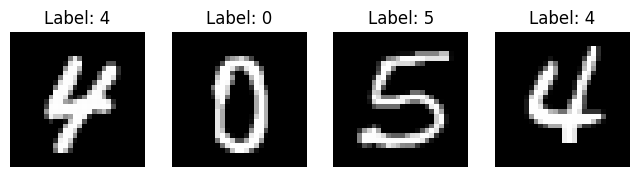

Batch Images Shape: torch.Size([64, 1, 28, 28])
Batch Labels Shape: torch.Size([64])


In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

BATCH_SIZE = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
plt.figure(figsize=(8, 3))
for i in range(4):
    plt.subplot(1, 4, i+1)
    img = images[i].squeeze() * 0.3081 + 0.1307
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')
plt.show()

print(f"Batch Images Shape: {images.shape}")
print(f"Batch Labels Shape: {labels.shape}")


In [9]:
class MNISTDigitClassifier(nn.Module):
    def __init__(self):
        super(MNISTDigitClassifier, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = MNISTDigitClassifier().to(device)
print(model)

dummy_input = torch.randn(32, 1, 28, 28).to(device)
dummy_output = model(dummy_input)
print(f"\nDry Run Output Shape: {dummy_output.shape}")


MNISTDigitClassifier(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Dry Run Output Shape: torch.Size([32, 10])


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (batch_idx + 1) % 200 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}], Step [{batch_idx+1}/{len(train_loader)}], Loss: {running_loss/200:.4f}")
            running_loss = 0.0


Epoch [1/5], Step [200/938], Loss: 0.4821
Epoch [1/5], Step [400/938], Loss: 0.1439
Epoch [1/5], Step [600/938], Loss: 0.1049
Epoch [1/5], Step [800/938], Loss: 0.0983
Epoch [2/5], Step [200/938], Loss: 0.0721
Epoch [2/5], Step [400/938], Loss: 0.0623
Epoch [2/5], Step [600/938], Loss: 0.0579
Epoch [2/5], Step [800/938], Loss: 0.0540
Epoch [3/5], Step [200/938], Loss: 0.0404
Epoch [3/5], Step [400/938], Loss: 0.0411
Epoch [3/5], Step [600/938], Loss: 0.0493
Epoch [3/5], Step [800/938], Loss: 0.0386
Epoch [4/5], Step [200/938], Loss: 0.0342
Epoch [4/5], Step [400/938], Loss: 0.0276
Epoch [4/5], Step [600/938], Loss: 0.0381
Epoch [4/5], Step [800/938], Loss: 0.0322
Epoch [5/5], Step [200/938], Loss: 0.0280
Epoch [5/5], Step [400/938], Loss: 0.0289
Epoch [5/5], Step [600/938], Loss: 0.0276
Epoch [5/5], Step [800/938], Loss: 0.0305


In [11]:
model.eval()
correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

average_test_loss = test_loss / len(test_loader)
accuracy = (correct / total) * 100

print(f"Evaluation Results:")
print(f"-------------------")
print(f"Average Test Loss: {average_test_loss:.4f}")
print(f"Test Accuracy: {accuracy:.2f}%")


Evaluation Results:
-------------------
Average Test Loss: 0.0287
Test Accuracy: 99.08%


Model weights saved successfully to 'mnist_cnn.pth'


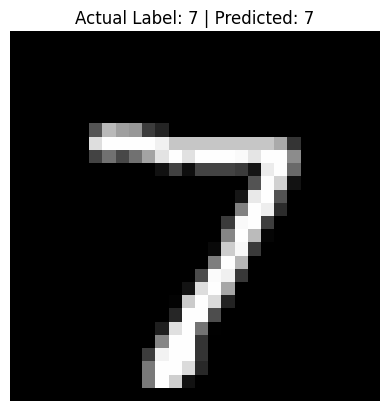

In [12]:
MODEL_PATH = "mnist_cnn.pth"
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model weights saved successfully to '{MODEL_PATH}'")

loaded_model = MNISTDigitClassifier().to(device)
loaded_model.load_state_dict(torch.load(MODEL_PATH))
loaded_model.eval()

images, labels = next(iter(test_loader))
single_img, single_label = images[0].unsqueeze(0).to(device), labels[0]

with torch.no_grad():
    prediction_logits = loaded_model(single_img)
    predicted_class = torch.argmax(prediction_logits, dim=1).item()

plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"Actual Label: {single_label.item()} | Predicted: {predicted_class}")
plt.axis('off')
plt.show()
